<a href="https://colab.research.google.com/github/sanikatakarkhede/ML_models-TAE-1/blob/main/Email_Spam_Detection(80_20).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TOPIC :- Email Spam Detection

ML TAE 1 - 80:20 Splitting

Group No.3: Riya Nitnaware_CS23015 , Sanika Takarkhede_CS23016

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
path = "/content/drive/MyDrive/ML_Dataset/spam.csv"
df = pd.read_csv(path, encoding='latin-1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [24]:
df = df.iloc[:, :2]
df.columns = ['label', 'message']
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [25]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['message'])
y = df['label']

In [26]:
def plot_confusion_matrix(cm, title):
    plt.imshow(cm, cmap='Blues')
    plt.title(title)
    plt.colorbar()

    plt.xticks([0,1], ['Ham','Spam'])
    plt.yticks([0,1], ['Ham','Spam'])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center')

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [27]:
print("========= 80:20 SPLIT =========")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

results = {}

========= 80:20 SPLIT =========


# Logistic Regression


--- Logistic Regression ---
Accuracy: 0.9632286995515695


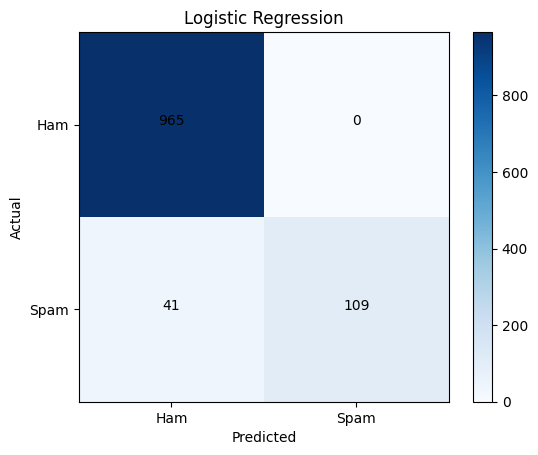

In [28]:
print("\n--- Logistic Regression ---")

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

pred = lr.predict(X_test)

acc = accuracy_score(y_test, pred)
print("Accuracy:", acc)

cm = confusion_matrix(y_test, pred)
plot_confusion_matrix(cm, "Logistic Regression")

results["Logistic Regression"] = acc

# Decision Tree


--- Decision Tree ---
Accuracy: 0.968609865470852


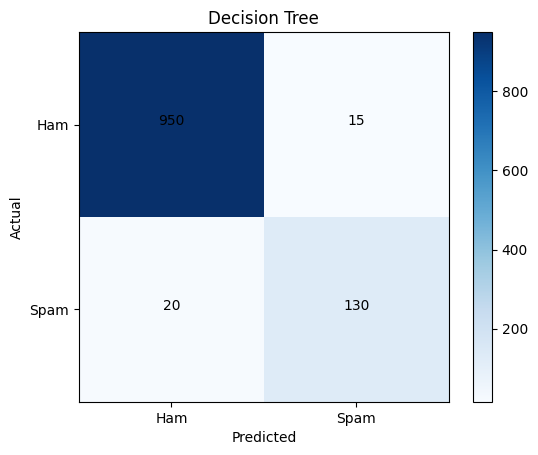

In [29]:
print("\n--- Decision Tree ---")

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

pred = dt.predict(X_test)

acc = accuracy_score(y_test, pred)
print("Accuracy:", acc)

cm = confusion_matrix(y_test, pred)
plot_confusion_matrix(cm, "Decision Tree")

results["Decision Tree"] = acc

# Naive Bayes


--- Naive Bayes ---
Accuracy: 0.9623318385650225


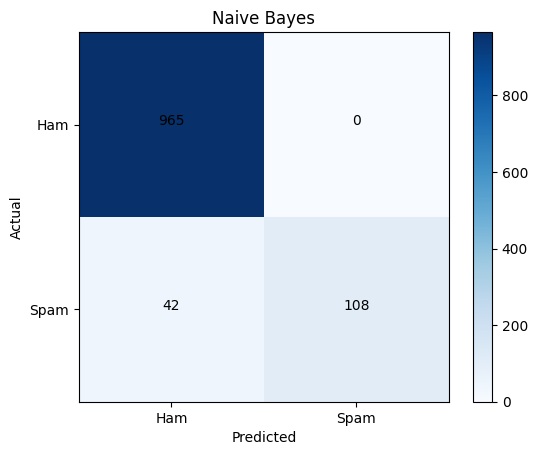

In [30]:
print("\n--- Naive Bayes ---")

nb = MultinomialNB()
nb.fit(X_train, y_train)

pred = nb.predict(X_test)

acc = accuracy_score(y_test, pred)
print("Accuracy:", acc)

cm = confusion_matrix(y_test, pred)
plot_confusion_matrix(cm, "Naive Bayes")

results["Naive Bayes"] = acc

# SVM


--- SVM ---
Accuracy: 0.9766816143497757


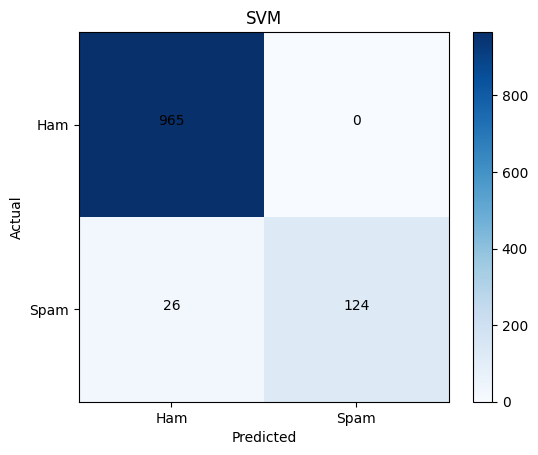

In [31]:
print("\n--- SVM ---")

svm = SVC()
svm.fit(X_train, y_train)

pred = svm.predict(X_test)

acc = accuracy_score(y_test, pred)
print("Accuracy:", acc)

cm = confusion_matrix(y_test, pred)
plot_confusion_matrix(cm, "SVM")

results["SVM"] = acc

# Random Forest


--- Random Forest ---
Accuracy: 0.9766816143497757


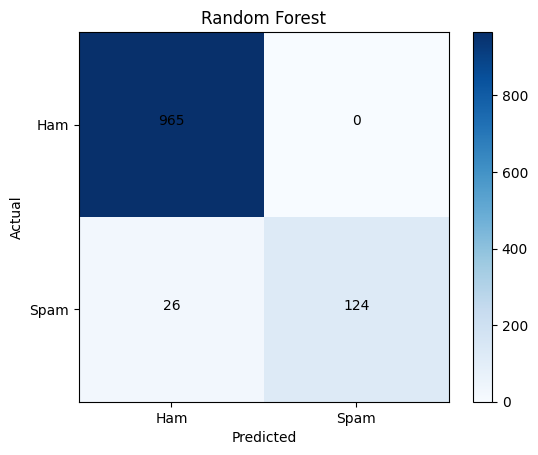

In [32]:
print("\n--- Random Forest ---")

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

pred = rf.predict(X_test)

acc = accuracy_score(y_test, pred)
print("Accuracy:", acc)

cm = confusion_matrix(y_test, pred)
plot_confusion_matrix(cm, "Random Forest")

results["Random Forest"] = acc

# KNN


--- KNN ---
Accuracy: 0.9130044843049328


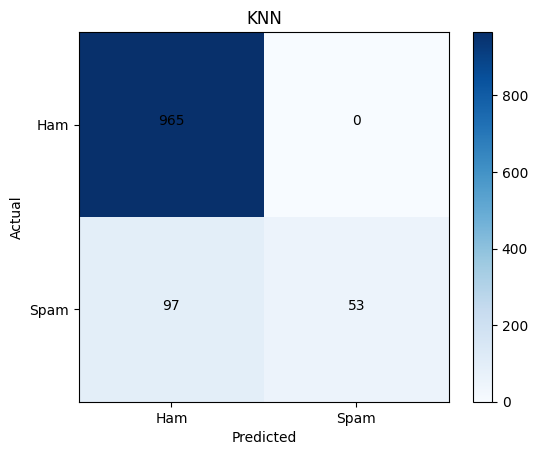

In [33]:
print("\n--- KNN ---")

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

pred = knn.predict(X_test)

acc = accuracy_score(y_test, pred)
print("Accuracy:", acc)

cm = confusion_matrix(y_test, pred)
plot_confusion_matrix(cm, "KNN")

results["KNN"] = acc

Accuracy Comparison Graph

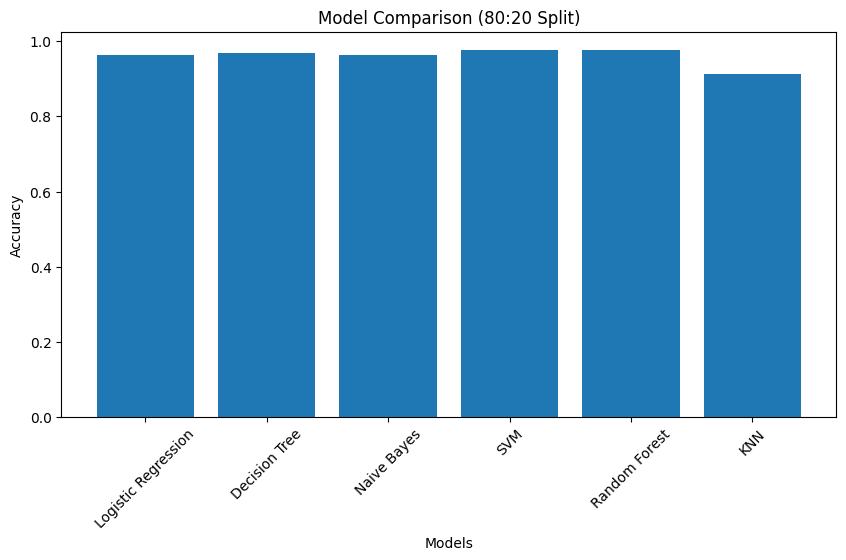

In [34]:
models = list(results.keys())
accuracy = list(results.values())

plt.figure(figsize=(10,5))
plt.bar(models, accuracy)

plt.title("Model Comparison (80:20 Split)")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=45)
plt.show()

In [35]:
print("\nFinal Accuracy Comparison:\n")

for model, acc in results.items():
    print(f"{model}: {acc:.4f}")


Final Accuracy Comparison:

Logistic Regression: 0.9632
Decision Tree: 0.9686
Naive Bayes: 0.9623
SVM: 0.9767
Random Forest: 0.9767
KNN: 0.9130


In [36]:
import pandas as pd

df_table = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": list(results.values())
})

df_table

,Model,Accuracy
0,Logistic Regression,0.963229
1,Decision Tree,0.968610
2,Naive Bayes,0.962332
3,SVM,0.976682
4,Random Forest,0.976682
5,KNN,0.913004


In [38]:
# BEST MODEL
best_model_name = df_table.loc[df_table["Accuracy"].idxmax(), "Model"]

print("\nBest Model:", best_model_name)

print("\n====== SPAM DETECTION ======")

# Create a dictionary of trained models
model_dict = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Naive Bayes": nb,
    "SVM": svm,
    "Random Forest": rf,
    "KNN": knn
}

# Select best model
final_model = model_dict[best_model_name]

import numpy as np

# Get sample spam and ham indices from TEST data
spam_index = np.where(y_test.values == 1)[0][:3]
ham_index = np.where(y_test.values == 0)[0][:3]

sample_index = np.concatenate([spam_index, ham_index])

# Sample test data
X_sample = X_test[sample_index]
y_actual = y_test.iloc[sample_index]

# Predictions
pred = final_model.predict(X_sample)

# Display results
for i in range(len(pred)):
    print("\n----------------------------")

    print("Message:", df.iloc[sample_index[i]]['message'])

    print("Actual:",
          "SPAM" if y_actual.iloc[i] == 1 else "NOT SPAM")

    print("Predicted:",
          "SPAM" if pred[i] == 1 else "NOT SPAM")


Best Model: SVM

====== SPAM DETECTION ======

----------------------------
Message: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Actual: SPAM
Predicted: SPAM

----------------------------
Message: Nah I don't think he goes to usf, he lives around here though
Actual: SPAM
Predicted: SPAM

----------------------------
Message: SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 4 info
Actual: SPAM
Predicted: SPAM

----------------------------
Message: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Actual: NOT SPAM
Predicted: NOT SPAM

----------------------------
Message: Ok lar... Joking wif u oni...
Actual: NOT SPAM
Predicted: NOT SPAM

----------------------------
Message: U dun say so early hor... U c already then say...
Actual: NOT